# House Price Prediction

## Week 1 Internship Project – Xylofy AI

### Submitted By:
**Krishnadas P S**
krishnadasps.mec@gmail.com

### Objective
The objective of this project is to build machine learning models that can predict house prices based on various property characteristics. The project includes data exploration, data preprocessing, model development, evaluation, visualization, and business insights.

---


# 1. Importing Required Libraries

In [12]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# 2. Loading the Dataset

In [13]:
df = pd.read_csv("Housing.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


# 3. Data Exploration

In [14]:
print("Dataset Shape:", df.shape)

print("\nColumns in Dataset:")
print(df.columns.tolist())

Dataset Shape: (545, 13)

Columns in Dataset:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [15]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [17]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [18]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [19]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


## Key Findings from Data Exploration

The housing dataset contains **545 records and 13 features**, making it suitable for building and evaluating machine learning regression models. The target variable for prediction is **price**, while the remaining columns represent various property characteristics such as area, number of bedrooms, bathrooms, stories, parking availability, and other amenities.

Initial data quality checks revealed that the dataset contains **no missing values and no duplicate records**, indicating that the data is clean and ready for further preprocessing and model development.

The dataset includes both **numerical features** (such as area, bedrooms, bathrooms, stories, and parking) and **categorical features** (such as main road access, guest room availability, basement availability, air conditioning, preferred area, and furnishing status). These categorical variables will require encoding before they can be used in machine learning models.

Preliminary statistical analysis suggests that property area may have a significant influence on house prices due to its wide range of values. Additional analysis will be performed in later stages to identify the most influential factors affecting property prices.


# 4. Data Cleaning and Preprocessing

In [20]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64

basement
basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea
prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


## Observations on Categorical Features

The dataset contains several categorical variables that describe property characteristics and amenities. Most categorical columns are binary in nature, containing only "yes" and "no" values, making them suitable for numerical encoding.

Features such as main road access, guest room availability, basement availability, hot water heating, air conditioning, and preferred area can be converted into binary numerical values (1 for "yes" and 0 for "no").

The furnishing status feature contains three categories: furnished, semi-furnished, and unfurnished. Since this feature has multiple categories, One-Hot Encoding will be applied to transform it into a machine-learning-friendly format without introducing artificial ordering between categories.

Converting categorical variables into numerical representations is an essential preprocessing step because machine learning algorithms require numerical inputs for model training and prediction.


In [21]:
# Create a copy of the dataset
df_processed = df.copy()

# Binary Encoding
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0})

# One-Hot Encoding
df_processed = pd.get_dummies(
    df_processed,
    columns=['furnishingstatus'],
    drop_first=True
)

print("Encoding Completed Successfully!")

Encoding Completed Successfully!


In [22]:
df_processed.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [23]:
df_processed = df_processed.astype({
    'furnishingstatus_semi-furnished': int,
    'furnishingstatus_unfurnished': int
})

df_processed.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


## Data Preprocessing Summary

The dataset required minimal cleaning because no missing values or duplicate records were present. However, categorical variables needed to be transformed into numerical representations before model training.

Binary categorical features were encoded using a simple mapping approach, where "yes" was converted to 1 and "no" was converted to 0. The furnishing status feature contained multiple categories and was therefore transformed using One-Hot Encoding. This created separate indicator variables while avoiding unnecessary ordinal relationships between categories.

The resulting dataset is fully numerical and ready for machine learning model development.


# 5. Feature Selection and Data Splitting

In [24]:
# Features (X) and Target (y)

X = df_processed.drop('price', axis=1)
y = df_processed['price']

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (545, 13)
Target Variable Shape: (545,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (436, 13)
Testing Set Shape: (109, 13)


## Feature Selection and Data Splitting

To prepare the dataset for machine learning, the target variable (**price**) was separated from the predictor variables. All remaining columns were used as input features for model training.

The dataset was then divided into training and testing subsets using an 80:20 ratio. The training set was used to train the machine learning models, while the testing set was reserved for evaluating model performance on unseen data.

A fixed random state value of 42 was used to ensure reproducibility of results, allowing the experiment to be repeated with consistent outcomes.


# 6. Linear Regression Model

In [26]:
# Create and train Linear Regression model

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [27]:
# Predictions

lr_predictions = lr_model.predict(X_test)

print("Predictions Generated Successfully!")

Predictions Generated Successfully!


In [28]:
# Evaluation Metrics

lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_predictions)
)

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("-" * 30)
print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.4f}")

Linear Regression Results
------------------------------
MAE  : 970043.40
RMSE : 1324506.96
R²   : 0.6529


## Linear Regression Model Evaluation

The Linear Regression model was trained using the prepared housing dataset and evaluated on the test set. The model achieved an R² score of approximately 0.65, indicating that it explains around 65% of the variation in house prices.

The Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) values suggest that while the model is able to capture the general relationship between property features and price, there are still prediction errors for some properties. This is expected because housing prices are influenced by complex relationships that may not be completely linear.

The Linear Regression model serves as a strong baseline and provides a useful benchmark for comparison with more advanced machine learning models.


# 7. Random Forest Regressor


In [29]:
# Create and train Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [30]:
rf_predictions = rf_model.predict(X_test)

print("Random Forest Predictions Generated Successfully!")

Random Forest Predictions Generated Successfully!


In [31]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("-" * 30)
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Results
------------------------------
MAE  : 1022560.05
RMSE : 1401496.84
R²   : 0.6114


In [32]:
print("Training R² Score:", rf_model.score(X_train, y_train))
print("Testing R² Score :", rf_model.score(X_test, y_test))

Training R² Score: 0.9498289117904977
Testing R² Score : 0.6114024924156645


Random Forest achieved a very high training R² score (0.95) but a significantly lower testing R² score (0.61), indicating overfitting. The model learned patterns specific to the training data but was less effective at generalizing to unseen properties. In contrast, Linear Regression achieved a better balance between training and testing performance, resulting in superior test-set accuracy.

In [33]:
rf_model_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

rf_model_tuned.fit(X_train, y_train)

rf_tuned_predictions = rf_model_tuned.predict(X_test)

rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_predictions)

rf_tuned_rmse = np.sqrt(
    mean_squared_error(y_test, rf_tuned_predictions)
)

rf_tuned_r2 = r2_score(
    y_test,
    rf_tuned_predictions
)

print("Tuned Random Forest Results")
print("-" * 35)
print(f"MAE  : {rf_tuned_mae:.2f}")
print(f"RMSE : {rf_tuned_rmse:.2f}")
print(f"R²   : {rf_tuned_r2:.4f}")

Tuned Random Forest Results
-----------------------------------
MAE  : 1088859.38
RMSE : 1447653.20
R²   : 0.5854


## Random Forest Analysis

A Random Forest Regressor was trained to compare its performance against the Linear Regression model. Although the Random Forest achieved excellent performance on the training dataset, its performance on the testing dataset was noticeably lower.

This behavior indicates overfitting, where the model learns patterns specific to the training data but struggles to generalize to unseen observations. Additional hyperparameter tuning was performed in an attempt to improve generalization; however, the tuned model did not outperform the baseline Linear Regression model.

These results suggest that the relationships within this housing dataset are relatively linear in nature, allowing the simpler Linear Regression model to achieve better predictive performance on unseen data.


# 8. Model Comparison

In [34]:
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Tuned Random Forest'
    ],
    'MAE': [
        lr_mae,
        rf_mae,
        rf_tuned_mae
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse,
        rf_tuned_rmse
    ],
    'R2 Score': [
        lr_r2,
        rf_r2,
        rf_tuned_r2
    ]
})

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402
2,Tuned Random Forest,1.088859e+06,1.447653e+06,0.585385


In [44]:
comparison_display = comparison_df.copy()

comparison_display['MAE'] = comparison_display['MAE'].map(lambda x: f"{x:,.2f}")

comparison_display['RMSE'] = comparison_display['RMSE'].map(lambda x: f"{x:,.2f}")

comparison_display['R2 Score'] = comparison_display['R2 Score'].round(4)

comparison_display

,Model,MAE,RMSE,R2 Score
0,Linear Regression,"970,043.40","1,324,506.96",0.6529
1,Random Forest,"1,022,560.05","1,401,496.84",0.6114
2,Tuned Random Forest,"1,088,859.38","1,447,653.20",0.5854


## Model Comparison Summary

Three regression models were evaluated to determine the most effective approach for predicting house prices. Performance was assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

Among all evaluated models, Linear Regression achieved the highest R² Score and the lowest prediction errors. Although Random Forest models are capable of capturing complex non-linear relationships, they exhibited signs of overfitting and were unable to outperform the simpler Linear Regression model on unseen data.

Based on these results, Linear Regression was selected as the best-performing model for this dataset and will be used for further analysis and visualization.


# 9. Data Visualization

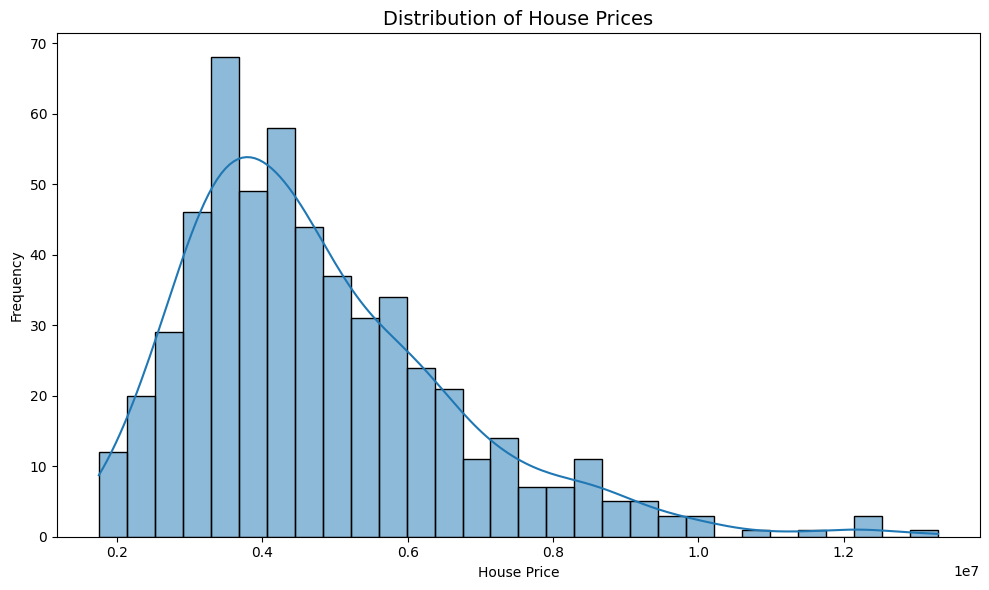

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['price'],
    bins=30,
    kde=True
)

plt.title(
    'Distribution of House Prices',
    fontsize=14
)

plt.xlabel('House Price')
plt.ylabel('Frequency')

plt.tight_layout()

plt.savefig(
    'charts/house_price_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

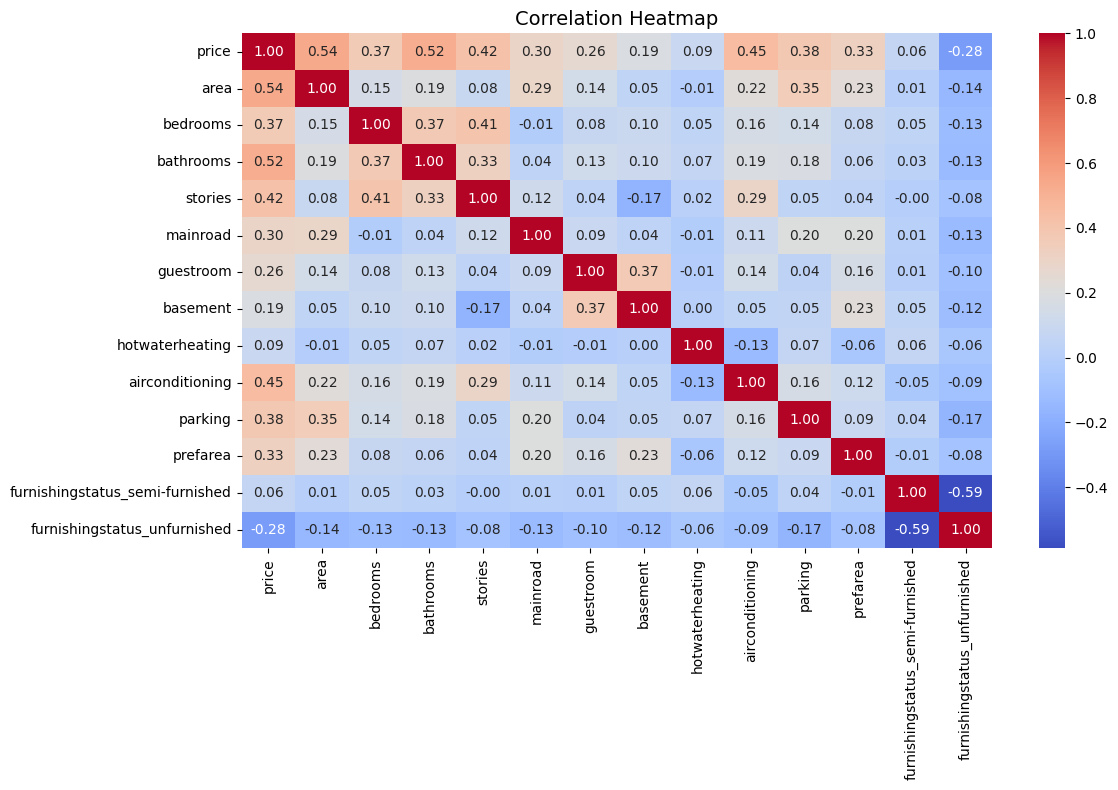

In [36]:
plt.figure(figsize=(12,8))

corr_matrix = df_processed.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    'Correlation Heatmap',
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    'charts/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

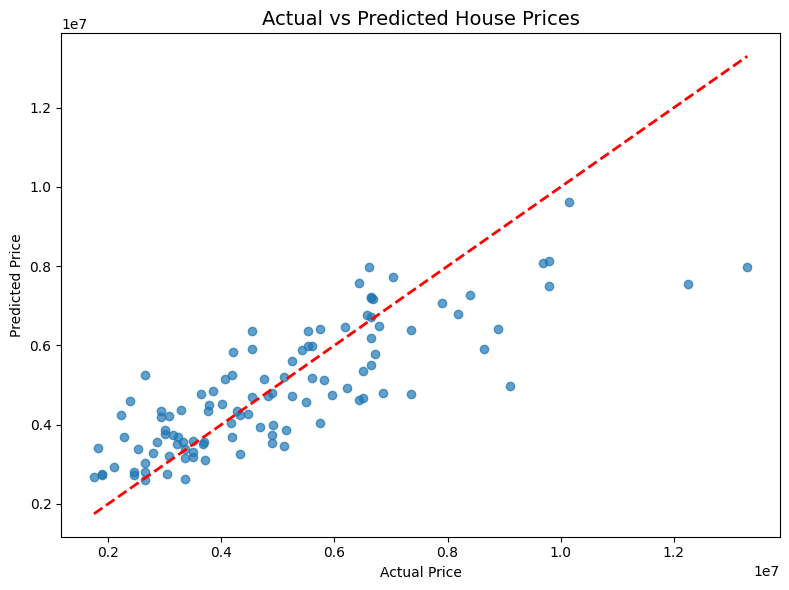

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lr_predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title(
    'Actual vs Predicted House Prices',
    fontsize=14
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.tight_layout()

plt.savefig(
    'charts/actual_vs_predicted.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [39]:
import os

print(os.listdir("charts"))

['actual_vs_predicted.png', 'correlation_heatmap.png', 'house_price_distribution.png']


# 10. Feature Importance Analysis

In [40]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,area,0.467917
2,bathrooms,0.151526
8,airconditioning,0.062718
9,parking,0.057820
3,stories,0.057137
1,bedrooms,0.048608
12,furnishingstatus_unfurnished,0.034998
6,basement,0.030804
10,prefarea,0.030519
7,hotwaterheating,0.017255


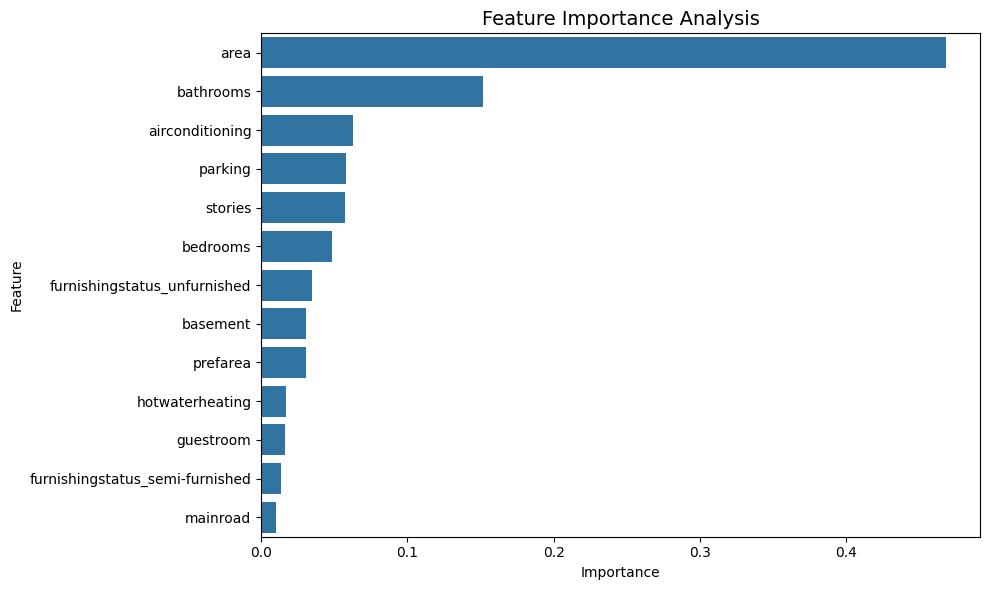

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Feature Importance Analysis',
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    'charts/feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Feature Importance Findings

Feature importance analysis was performed using the Random Forest model to identify which property characteristics contribute most significantly to house price prediction.

The results indicate that property area is the most influential factor, contributing nearly half of the total predictive importance. Bathrooms were identified as the second most important feature, followed by air conditioning, parking availability, and the number of stories.

These findings are consistent with the correlation analysis, which also showed strong relationships between house prices and structural property characteristics. The results suggest that larger homes with more bathrooms and additional amenities tend to command higher market prices.

Understanding these influential factors can help real estate businesses prioritize property features that have the greatest impact on valuation and customer demand.


In [42]:
feature_importance.head(5)

,Feature,Importance
0,area,0.467917
2,bathrooms,0.151526
8,airconditioning,0.062718
9,parking,0.057820
3,stories,0.057137


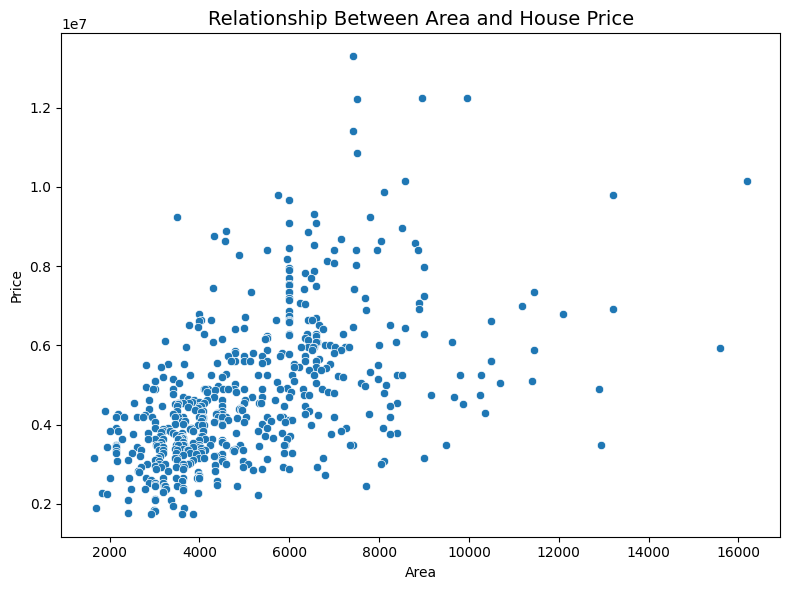

In [43]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='area',
    y='price'
)

plt.title(
    'Relationship Between Area and House Price',
    fontsize=14
)

plt.xlabel('Area')
plt.ylabel('Price')

plt.tight_layout()

plt.savefig(
    'charts/price_vs_area.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 11. Conclusions and Business Recommendations

### Key Findings

The analysis revealed that property area is the most influential factor affecting house prices, followed by the number of bathrooms, air conditioning availability, parking facilities, and the number of stories. Both correlation analysis and feature importance analysis consistently identified these variables as the strongest predictors of property value.

### Model Performance

Among the evaluated machine learning models, Linear Regression achieved the best performance with an R² score of approximately 0.65. This indicates that the model is able to explain around 65% of the variation in house prices based on the available property features.

### Interesting Observation

One surprising finding was that the Linear Regression model outperformed both the Random Forest and Tuned Random Forest models on the test dataset. Further investigation showed that the Random Forest model suffered from overfitting, suggesting that the relationships within this dataset are relatively linear and can be effectively captured by a simpler model.

### Business Recommendation

Real estate businesses should pay particular attention to property area, bathroom count, and key amenities such as air conditioning and parking facilities when pricing properties. These features have the strongest impact on house value and can significantly influence buyer demand and market valuation.


## Conclusion

This project successfully developed and evaluated machine learning models for predicting house prices using property characteristics and amenities. A complete data science workflow was followed, including data exploration, preprocessing, model development, performance evaluation, visualization, and business analysis.

Among the evaluated models, Linear Regression achieved the best predictive performance on unseen data, with an R² score of approximately 0.65. Although Random Forest models were also tested, they exhibited signs of overfitting and did not outperform the simpler Linear Regression approach.

Feature importance and correlation analyses consistently identified property area, number of bathrooms, air conditioning, parking availability, and number of stories as the most influential factors affecting house prices. These findings provide valuable insights for real estate pricing and investment decisions.

Overall, the project demonstrates how machine learning techniques can support data-driven decision-making in the real estate industry by identifying key drivers of property value and generating reliable price predictions.
